<a href="https://colab.research.google.com/github/Bet-Zawl/TP_project/blob/main/TP4_Data_Cleansing_TP4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP4 - Validation et Cohérence des Données

**Difficulté:** Intermédiaire  
**Dataset:** healthcare_inconsistent.csv  
**Description:** Vérification des contraintes logiques et cohérence inter-colonnes

---


## Imports des Bibliothèques


In [93]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import pandera as pa
from pandera import Column, DataFrameSchema
import great_expectations as ge

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [94]:
# Charger le dataset
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/data_cleaning_project/healthcare_inconsistent.csv'
df = pd.read_csv(file_path)

#df = pd.read_csv('healthcare_inconsistent.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📏 Dimensions: 300 lignes × 9 colonnes
 Taille mémoire: 0.08 MB




,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int64  
 2   birth_date   300 non-null    object 
 3   email        300 non-null    object 
 4   start_date   300 non-null    object 
 5   end_date     300 non-null    object 
 6   price        300 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

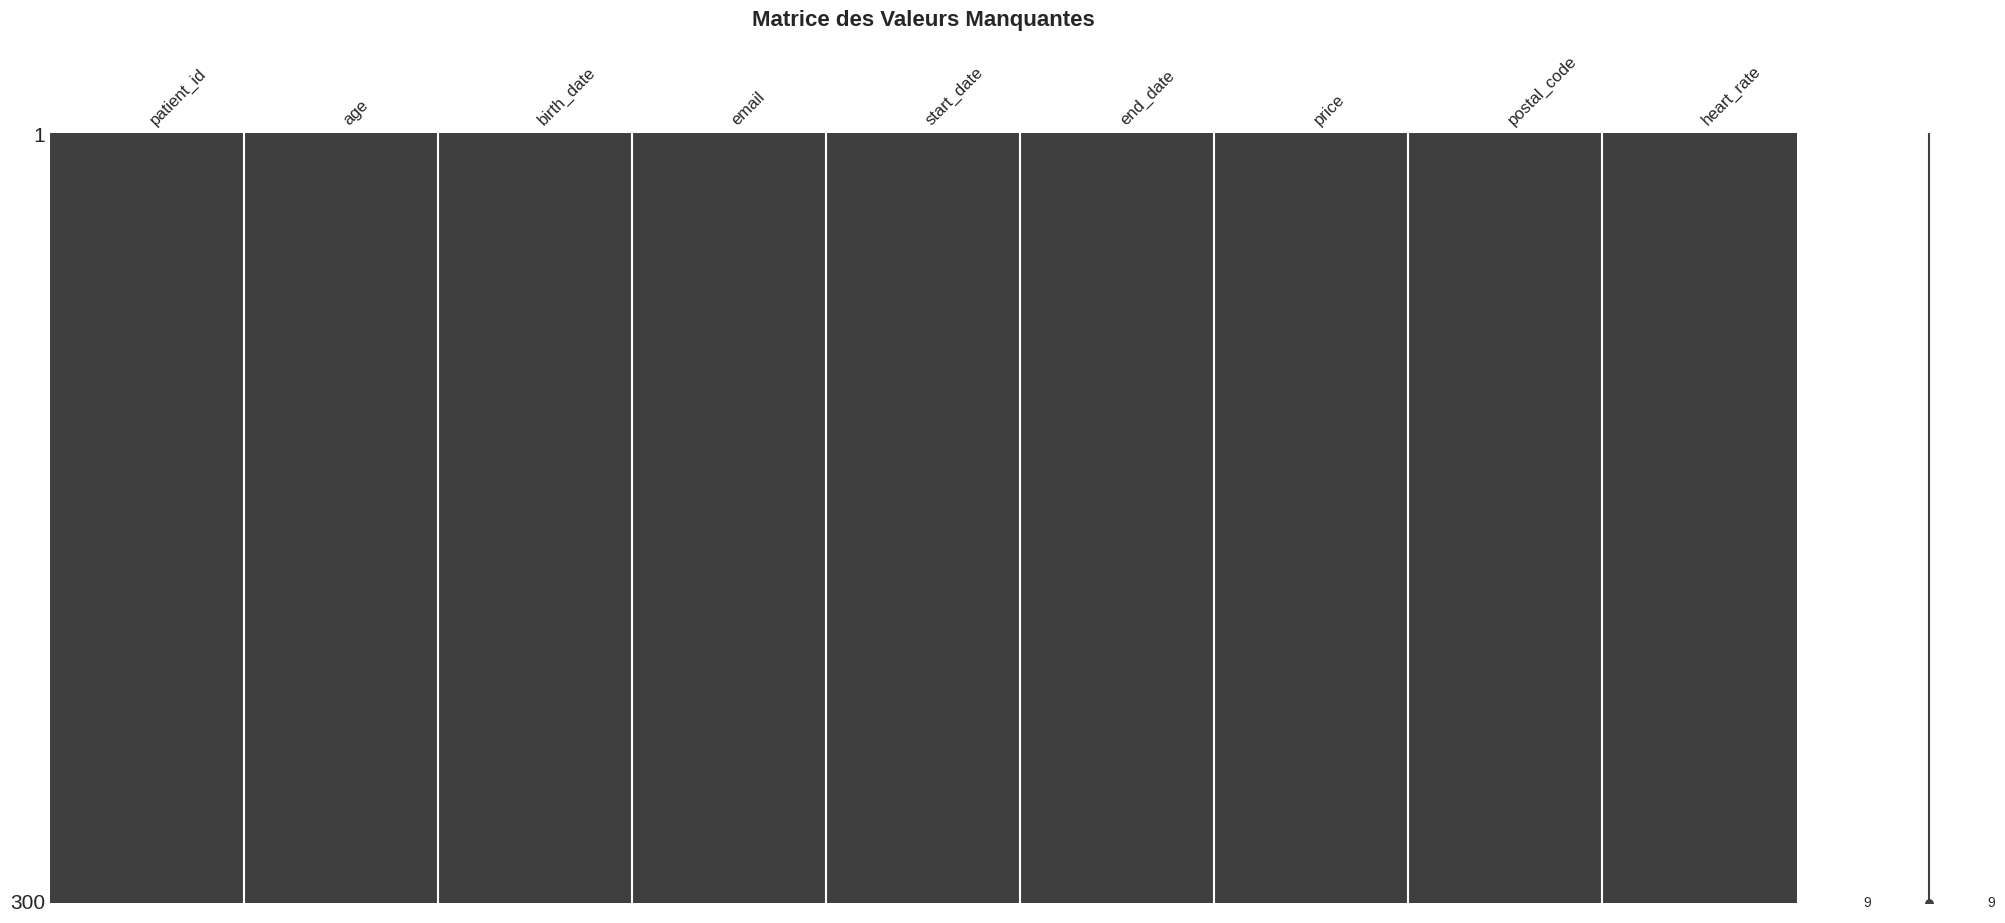


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [95]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
2. Les dates de fin sont-elles toujours après les dates de début ?
3. Y a-t-il des emails sans '@' ?
4. Les codes postaux respectent-ils le format attendu ?
5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
6. Les prix sont-ils tous positifs ?
7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?
8. Les unités de mesure sont-elles cohérentes ?
9. Combien d'enregistrements violent au moins une contrainte ?
10. Quelle contrainte est la plus souvent violée ?


In [96]:
#  Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici


Réponses aux questions:


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Définir un dictionnaire de contraintes de validation
### Étape 2: Créer une fonction validate_constraints(df)
### Étape 3: Valider les plages numériques (âge, prix, etc.)
### Étape 4: Valider les formats (email, téléphone, code postal)
### Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
### Étape 6: Créer des indicateurs pour chaque violation
### Étape 7: Décider des actions correctives pour chaque type
### Étape 8: Appliquer les corrections
### Étape 9: Standardiser les unités de mesure
### Étape 10: Générer un rapport de validation complet


In [97]:
# ========================================
# Étape 1: Définir un dictionnaire de contraintes de validation
# ========================================

# TODO: Écrivez votre code ici

# Dictionnaire de constraints de violation

Constraints = DataFrameSchema({
    'age': Column(int, checks=pa.Check.in_range(1,120), nullable=True),
    'price': Column(float, checks=pa.Check.greater_than_or_equal_to(0), nullable=True),
    'heart_rate': Column(int, checks=pa.Check.in_range(40,200), nullable=True),
    'email': Column(str),  # Corrected from dict to Column(str)
    'postal_code': Column(str),
    'start_date': Column(str),
    'birth_date': Column(str)
})
# Vérification
print(f" Étape 1 complétée")

 Étape 1 complétée


In [98]:
# ========================================
# Étape 2: Créer une fonction validate_constraints(df)
# ========================================
df_validated = df.copy()
def validate_constraints(df):
  for col in df.columns:
    if col in Constraints.columns:
      try:
        validated_df = Constraints.validate(df_validated, lazy=True) # lazy=True collects all errors
        print("DataFrame is valid:\n", validated_df.shape)
      except pa.errors.SchemaErrors as err:
          print("Validation errors:\n", err.failure_cases.shape)

# Vérification
print(f" Étape 2 complétée")

 Étape 2 complétée


In [99]:
# ========================================
# Étape 3: Valider les plages numériques (âge, prix, etc.)
# ========================================

# TODO: Écrivez votre code ici

def validate_plages_numerique(df, col1,col2, col3):
  Columns = [col1, col2, col3]
  for col in Columns:
    if col in Columns:
      try:
        validated_df = Constraints.validate(df_validated, lazy=True) # lazy=True collects all errors
        print("DataFrame is valid:\n", validated_df.shape)
      except pa.errors.SchemaErrors as err:
          print("Validation errors:\n", err.failure_cases.shape)
# Valider le DataFrame
validate_plages_numerique(df_validated, 'age', 'price', 'heart_rate') #validation pour âge, prix, heart_rate

# Vérification
print(f" Étape 3 complétée")

Validation errors:
 (389, 6)
Validation errors:
 (389, 6)
Validation errors:
 (389, 6)
 Étape 3 complétée


In [100]:
# ========================================
# Étape 4: Valider les formats (email, téléphone, code postal)
# ========================================

# TODO: Écrivez votre code ici
def validate_formats(df):
  formats = {
      'email': r"^[^@]+@[^@]+\.[^@]+$",
      'postal_code': r"^\d{5}(?:[-\s]\d{4})?$"
  }
  for col, regex in formats.items():
    try:
      validated_df = Constraints.validate(df_validated, lazy=True) # lazy=True collects all errors
      print("DataFrame is valid:\n", validated_df.shape)
    except pa.errors.SchemaErrors as err:
        print("Validation errors:\n", err.failure_cases.shape)

#validation de text
validate_formats(df_validated)
# Vérification
print(f" Étape 4 complétée")

Validation errors:
 (389, 6)
Validation errors:
 (389, 6)
 Étape 4 complétée


In [101]:
# ========================================
# Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
# ========================================

# TODO: Écrivez votre code ici
# Année courante
def date_incoherence(data):
  start_date = datetime.now().year
  df['start_date'] = pd.to_datetime(start_date, errors='coerce')
# Convertir la date de naissance en datetime
  df["birth_date"] = pd.to_datetime(df["birth_date"], errors="coerce")

# Calculer l'âge théorique
  df["age_calc"] = df['start_date'].dt.year - df["birth_date"].dt.year

# Vérifier les incohérences
  df["age_incoherent"] = df["age"] != df["age_calc"]

# Afficher les lignes incohérentes
  incoherences = df[df["age_incoherent"]]
#print(df_validated.head(3))
#print(incoherences)
  print(len(incoherences))
date_incoherence(df_validated)

# Vérification
print(f" Étape 5 complétée")


297
 Étape 5 complétée


In [102]:
# ========================================
# Étape 6: Créer des indicateurs pour chaque violation
# ========================================

# TODO: Écrivez votre code ici
def validation_indicators(df):
    errors = []
    # Contrainte 1: Date de fin après date de début
    if 'start_date' in df.columns and 'end_date' in df.columns:
        invalid = df[df['end_date'] < df['start_date']]
        if len(invalid) > 0:
            errors.append(f"Dates incohérentes: {len(invalid)} lignes")
    # Contrainte 2: Age entre 0 et 120
    if 'age' in df.columns:
        invalid = df[(df['age'] < 0) | (df['age'] > 120)]
        if len(invalid) > 0:
            errors.append(f"Ages invalides: {len(invalid)} lignes")

    # Contrainte 3: Prix positifs
    price_cols = [col for col in df.columns if 'price' in col.lower()]
    for col in price_cols:
        invalid = df[df[col] < 0]
        if len(invalid) > 0:
            errors.append(f"{col} negatifs: {len(invalid)} lignes")

    # Contrainte 5: Heart rate valids
    if 'heart_rate' in df.columns:
        invalid = df[(df['heart_rate'] < 40) | (df['heart_rate'] > 200)]
        if len(invalid) > 0:
            errors.append(f"Heart rate invalides: {len(invalid)} lignes")

    # Contrainte 4: Emails valides
    if 'email' in df.columns:
        email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'
        invalid = df[~df['email'].str.match(email_pattern, na=False)]
        if len(invalid) > 0:
            errors.append(f"Emails invalides: {len(invalid)} lignes")

    return print(f"Validation Indicators: {errors}")

# Verification
validation_indicators(df_validated)

# Vérification
print(f" Étape 6 complétée")

Validation Indicators: ['Dates incohérentes: 5 lignes', 'Ages invalides: 10 lignes', 'price negatifs: 6 lignes', 'Heart rate invalides: 71 lignes', 'Emails invalides: 8 lignes']
 Étape 6 complétée


In [103]:
# ========================================
# Étape 7: Décider des actions correctives pour chaque type
# ========================================

# TODO: Écrivez votre code ici

def correction_print(df):
  # Replace unrealistic ages with NaN
  df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

  # Replace unrealistic prices with NaN
  df.loc[df["price"] < 0, "price"] = np.nan

  # Replace unrealistic heart rates with NaN
  df.loc[(df["heart_rate"] < 40) | (df["heart_rate"] > 200), "heart_rate"] = np.nan

  # Replace invalid emails with NaN
  # Fix: Ensure the column is treated as strings and handle NaN with na=False
  df.loc[~df["email"].astype(str).str.contains("@", na=False), "email"] = np.nan

  return display(f"Correction Print: {df.info()}")

correction_print(df_validated)


# Vérification
print(f" Étape 7 complétée 7")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          290 non-null    float64
 2   birth_date   300 non-null    object 
 3   email        292 non-null    object 
 4   start_date   300 non-null    object 
 5   end_date     300 non-null    object 
 6   price        294 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   229 non-null    float64
dtypes: float64(3), int64(2), object(4)
memory usage: 21.2+ KB


'Correction Print: None'

 Étape 7 complétée 7


In [104]:
# ========================================
# Étape 8: Appliquer les corrections
# ========================================
df_corrected =df_validated.copy()
# TODO: Écrivez votre code ici
def apply_corrections(df):
  # Apply corrections
  if df['age'].isna().any():
    df['age'] = df['age'].fillna(df['age'].median())
  if df['price'].isna().any():
    df['price'] = df['price'].fillna(df['price'].median())
  if df['heart_rate'].isna().any():
    df['heart_rate'] = df['heart_rate'].fillna(df['heart_rate'].median())
  if df['email'].isna().any():
    df['email'] = df['email'].dropna()
  if df['postal_code'].isna().any():
    df['postal_code'] = df['postal_code'].fillna(df['postal_code'].mode()[0])

  return print(f"Apply Corrections: {df.shape}")

apply_corrections(df_corrected)

# Vérification
print(f" Étape 8 complétée")

Apply Corrections: (300, 9)
 Étape 8 complétée


In [105]:
# ========================================
# Étape 9: Standardiser les unités de mesure
# ========================================

# TODO: Écrivez votre code ici

def standardize_unités_mesure(df):
  numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Vérification
print(f" Étape 9 complétée")

 Étape 9 complétée


In [106]:
# ========================================
# Étape 10: Générer un rapport de validation complet
# ========================================

# TODO: Écrivez votre code ici
def validate_dataset(df):
    """Suite complète de validation des données"""
    validation_results = {
        'passed': [],
        'failed': [],
        'warnings': []
    }

    # 1. Vérification de la structure
    expected_columns = ['patient_id', 'age', 'birth_date', 'email',
                        'start_date', 'end_date', 'price',
                        'postal_code', 'heart_rate'
                        ]
    missing_cols = set(expected_columns) - set(df.columns)
    if missing_cols:
        validation_results['failed'].append(f"Colonnes manquantes: {missing_cols}")
    else:
        validation_results['passed'].append("Structure correcte")

    # 2. Vérification des types
    type_checks = { 'patient_id':'float64', 'age':'float64', 'birth_date':'object', 'email':'object',
                   'start_date':'object', 'end_date':'object',
                   'price':'float64', 'postal_code':'object', 'heart_rate':'float64'
                   }
    for col, expected_type in type_checks.items():
        if col in df.columns:
            if df[col].dtype.name != expected_type:
                validation_results['warnings'].append(
                    f"{col}: type {df[col].dtype} au lieu de {expected_type}"
                )

    # 3. Vérification des valeurs nulles
    null_threshold = 0.05
    for col in df.columns:
        null_ratio = df[col].isna().mean()
        if null_ratio > null_threshold:
            validation_results['failed'].append(
                f"{col}: {null_ratio:.1%} de valeurs manquantes"
            )

    # 4. Vérification des doublons
    duplicate_ratio = df.duplicated().mean()
    if duplicate_ratio > 0.01:
        validation_results['warnings'].append(
            f"{duplicate_ratio:.1%} de doublons détectés"
        )
    if duplicate_ratio > 0.01:
        validation_results['warnings'].append(
            f"{duplicate_ratio:.1%} de doublons détectés"
        )

    # 5. Contraintes métier

    if 'age' in df.columns:
        invalid_age = (df['age'] < 0) | (df['age'] > 120)
        if invalid_age.any():
            validation_results['failed'].append(f"{invalid_age.sum()} ages invalides")
    if 'price' in df.columns:
        invalid_price = df['price'] < 0
        if invalid_price.any():
            validation_results['failed'].append(f"{invalid_price.sum()} prix négatifs")

    if 'heart_rate' in df.columns:
        invalid_heart_rate = (df['heart_rate'] < 40) | (df['heart_rate'] > 200)
        if invalid_heart_rate.any():
            validation_results['failed'].append(f"{invalid_heart_rate.sum()} taux d'coeur invalides")
    if 'email' in df.columns:
        invalid_email = ~df['email'].str.contains('@', na=False)
        if invalid_email.any():
            validation_results['failed'].append(f"{invalid_email.sum()} emails invalides")

    stats = {
        'n_rows': len(df),
        'n_columns': len(df.columns),
        'memory_usage': df.memory_usage(deep=True).sum() / 1024**2,
        'null_percentage': df.isna().mean().mean() * 100
    }
    return validation_results, stats

# Utilisation
results, stats = validate_dataset(df_corrected)
print("Tests passés:")
for test in results['passed']:
    print(f"  - {test}")
print("Avertissements:")
for warning in results['warnings']:
    print(f"  - {warning}")
print("Tests échoués:")
for fail in results['failed']:
    print(f"  - {fail}")
print(f"Statistiques: {stats['n_rows']:,} lignes, {stats['n_columns']} colonnes")

# Vérification
print(f" Étape 10 complétée")

Tests passés:
  - Structure correcte
Avertissements:
  - patient_id: type int64 au lieu de float64
  - postal_code: type int64 au lieu de object
Tests échoués:
  - 8 emails invalides
Statistiques: 300 lignes, 9 colonnes
 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [107]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 0,
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': []
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (300, 11)
Dimensions_finales...................... (300, 11)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. []

 TP terminé avec succès!
